# Análise principal — Seazone Jovens Talentos 2026
## Ranking de investimento em short-stay — Itapema (SC)

Fluxo linear: preparação → Cap Rate (métrica A) → sensibilidade de ocupação → ocupação diferencial por bairro → eficiência por m² (métrica C) → ranking com coluna de confiança → deep-dive → cartão do investimento → mapas → considerações finais.

Decisões metodológicas consolidadas em `docs/metodologia.md`. Arquivos brutos em `data/` (imutáveis).

## 0. Importações e helpers

- normalização de bairro (mapa humano em `docs/metodologia.md`)
- bin de tipologia (apartamentos): 1qto (0-1), 2q, 3q, 4q+
- corte de outliers por quantil (1-99%)

In [1]:
import pandas as pd
import numpy as np
import unicodedata

def norm(s):
    if not isinstance(s, str):
        return s
    return unicodedata.normalize('NFD', s).encode('ascii', 'ignore').decode().strip().lower()

MERGERS = {
    'jardim praiamar': 'jardim praia mar',
    'meia praia - frente mar': 'meia praia',
    'taboleiro': 'tabuleiro dos oliveiras',
    'tabuleiro': 'tabuleiro dos oliveiras',
}

def bairro_canonic(s):
    n = norm(s)
    return MERGERS.get(n, n)

def bin_tipo(nb):
    """Bin de tipologia de apartamento por nº de quartos."""
    if nb <= 1:
        return '1qto'
    if nb == 2:
        return '2q'
    if nb == 3:
        return '3q'
    return '4q+'

def clip_outliers(df, col, q_lo=0.01, q_hi=0.99):
    lo, hi = df[col].quantile([q_lo, q_hi])
    return df[(df[col] >= lo) & (df[col] <= hi)]

# ---------------------------------------------------------------- formatacao pt-BR
# Os numeros sao exibidos no padrao brasileiro (milhar com ponto, decimal com
# virgula). O padrao do Python e o ingles ("877,500" = 877 mil), que num relatorio
# em portugues se le como 877 reais e 50 centavos.
def num_br(v, dec=0):
    """1234567.8 -> '1.234.567,8' (dec=1)."""
    s = '{:,.{}f}'.format(v, dec)
    # troca via sentinela para nao sobrescrever o separador ja convertido
    return s.replace(',', '\x00').replace('.', ',').replace('\x00', '.')

def brl(v, dec=0):
    """877500 -> 'R$ 877.500'."""
    return 'R$ ' + num_br(v, dec)

def brl_faixa(lo, hi, dec=0):
    """Faixa de valor com UM sinal de $.

    Dois '$' no mesmo texto viram delimitador de LaTeX inline: o MathJax do
    nbconvert captura 'R$ 108.405 a R$ 117.439' e tipografa o meio como
    matematica (sai em serif italico e ilegivel). Um '$' so nao dispara.
    """
    return 'R$ {} a {}'.format(num_br(lo, dec), num_br(hi, dec))

def pct_br(v, dec=1):
    """0.134 -> '13,4%'."""
    return num_br(v * 100, dec) + '%'


## 1. Preparação — lado Airbnb (receita)

Junta `Details` (tipologia) + `Mesh` (bairro) + `Price_AV` (R$/noite).
Exclui: `none`, `hotel`, `terreno`, `comercial`, `outros`, `casas`.
Tipologia binada como `1qto/2q/3q/4q+`.

In [2]:
BASE = '../data/'
D = pd.read_csv(f'{BASE}Details_Itapema.csv', encoding='utf-8',
                usecols=['airbnb_listing_id', 'number_of_bedrooms', 'listing_type', 'owner_id', 'star_rating', 'number_of_reviews', 'picture_count', 'min_nights', 'cleaning_fee', 'number_of_guests', 'is_professional', 'can_instant_book', 'is_guest_favorite'])
M = pd.read_csv(f'{BASE}Mesh_Ids_Data_Itapema.csv', encoding='utf-8',
                usecols=['airbnb_listing_id', 'suburb'])
M = M[M['suburb'].str.lower() != 'none'].dropna(subset=['suburb'])
M['bairro'] = M['suburb'].map(bairro_canonic)
P = pd.read_csv(f'{BASE}Price_AV_Itapema.csv', encoding='utf-8',
                usecols=['airbnb_listing_id', 'price'])

air = (D.merge(M[['airbnb_listing_id', 'bairro']], on='airbnb_listing_id', how='inner')
         .merge(P, on='airbnb_listing_id', how='inner'))
air = air[air['listing_type'] == 'apartamento']
air['tipo'] = air['number_of_bedrooms'].map(bin_tipo)

print('listings Airbnb (apartamento, com preço):', air['airbnb_listing_id'].nunique())
# Previa de leitura (5 primeiros registros, colunas essenciais)
print('Amostra dos dados carregados (5 primeiros registros):')
_preview = air[['bairro','tipo','price']].head(5).copy()
_preview.columns = ['Bairro','Tipologia','R$/noite']
_preview['R$/noite'] = _preview['R$/noite'].map(lambda v: f'R$ {v:,.0f}')
display(_preview.style.hide(axis="index").set_table_attributes('class="no-index"'))


listings Airbnb (apartamento, com preço): 911
Amostra dos dados carregados (5 primeiros registros):


Bairro,Tipologia,R$/noite
meia praia,3q,R$ 471
meia praia,3q,R$ 673
meia praia,3q,R$ 572
meia praia,3q,R$ 743
meia praia,3q,R$ 680


## 2. Preparação — lado VivaReal (preço de compra)

Filtra `apartamento`, `sale_price` > 0, outlier 1-99%, tipologia binada.

In [3]:
V = pd.read_csv(f'{BASE}VivaReal_Itapema.csv', encoding='utf-8',
                usecols=['suburb', 'bedrooms', 'listing_type', 'sale_price', 'usable_area'])
V = V[(V['listing_type'] == 'apartamento') & (V['sale_price'] > 0)]
V = V.dropna(subset=['suburb'])
V['bairro'] = V['suburb'].map(bairro_canonic)
V['tipo'] = V['bedrooms'].map(bin_tipo)
V = clip_outliers(V, 'sale_price')

print('anúncios VivaReal (apartamento):', len(V))

# Previa de leitura (5 primeiros registros, colunas essenciais)
print('Amostra dos dados carregados (5 primeiros registros):')
_preview_v = V[['bairro','tipo','sale_price','usable_area']].head(5).copy()
_preview_v.columns = ['Bairro','Tipologia','Preço de compra','Área m²']
_preview_v['Preço de compra'] = _preview_v['Preço de compra'].map(lambda v: f'R$ {v:,.0f}')
_preview_v['Área m²'] = _preview_v['Área m²'].map(lambda v: f'{v:,.0f} m²')
display(_preview_v.style.hide(axis='index').set_table_attributes('class=\"no-index\"'))


anúncios VivaReal (apartamento): 7297
Amostra dos dados carregados (5 primeiros registros):


Bairro,Tipologia,Preço de compra,Área m²
meia praia,3q,"R$ 1,598,122",131 m²
meia praia,3q,"R$ 1,450,000",118 m²
castelo branco,3q,"R$ 1,500,000",125 m²
morretes,2q,"R$ 870,000",70 m²
andorinha,3q,"R$ 2,150,000",130 m²


## 3. Tabela cruzada bairro × tipo

Agrega por célula: nº de listings Airbnb, nº de anúncios de venda,
mediana R$/noite, mediana de preço de compra.
Aplica corte de volume **N≥20 (Airbnb) e M≥15 (VivaReal)** por célula.

**Advertência**: a janela jan–abr (verão) superestima receita anualizada.
O resultado é apresentado como **Cap Rate de pico/verão**, não média anual.

In [4]:
cnt = air.groupby(['bairro', 'tipo'])['airbnb_listing_id'].nunique().rename('n_airbnb')
rec = air.groupby(['bairro', 'tipo'])['price'].median().rename('price_med_noite')
nviv = V.groupby(['bairro', 'tipo']).size().rename('n_vivareal')
prec = V.groupby(['bairro', 'tipo'])['sale_price'].median().rename('sale_price_med')
area = V.groupby(['bairro', 'tipo'])['usable_area'].median().rename('area_med_m2')

tab = (pd.DataFrame({'price_med_noite': rec, 'sale_price_med': prec,
                     'n_vivareal': nviv, 'area_med_m2': area})
         .merge(cnt, on=['bairro', 'tipo'], how='left').reset_index())
tab = tab[(tab['n_airbnb'] >= 20) & (tab['n_vivareal'] >= 15)].copy()
tab['n_airbnb'] = tab['n_airbnb'].astype(int)
tab = tab.sort_values(['bairro', 'tipo']).reset_index(drop=True)

# exibição de leitura (colunas internas ficam no background)
_tab_leitura = tab.copy()
_tab_leitura.columns = ['Bairro','Tipo','R$/noite','Preço compra','Qtd venda','Área m²','Qtd Airbnb']
_tab_leitura = _tab_leitura[['Bairro','Tipo','Qtd Airbnb','Qtd venda','R$/noite','Preço compra','Área m²']]
_tab_leitura['R$/noite'] = _tab_leitura['R$/noite'].map(brl)
_tab_leitura['Preço compra'] = _tab_leitura['Preço compra'].map(brl)
display(_tab_leitura.style.hide(axis='index').set_table_attributes('class=\"no-index\"'))

Bairro,Tipo,Qtd Airbnb,Qtd venda,R$/noite,Preço compra,Área m²
centro,1qto,78,18.000000,R$ 471,R$ 895.000,53.000000
centro,2q,65,89.000000,R$ 611,R$ 1.150.000,86.000000
centro,3q,45,438.000000,R$ 749,R$ 2.100.000,131.000000
meia praia,1qto,28,58.000000,R$ 495,R$ 877.500,40.000000
meia praia,2q,187,244.000000,R$ 500,R$ 1.075.000,85.000000
meia praia,3q,327,1704.000000,R$ 712,R$ 1.884.860,129.000000
meia praia,4q+,65,1375.000000,R$ 1.300,R$ 3.671.338,188.000000
morretes,2q,51,1010.000000,R$ 500,R$ 793.950,69.000000


## 4. Cap Rate short-stay (métrica A)

`cap_rate(ocupação) = ocupação × R$/noite × 365 ÷ preço de compra`

Como a ocupação real não está nos dados, apresentamos o multiplicador `k = R$/noite × 365 ÷ preço`
e o Cap Rate para ocupações de cenário. **O ranking por `k` independe da ocupação** (ocupação
só escalona os valores, não reordena).

In [5]:
tab['k'] = tab['price_med_noite'] * 365 / tab['sale_price_med']
for o in [0.4, 0.5, 0.6, 0.7, 0.8]:
    tab[f'cap_{int(o*100)}'] = tab['k'] * o
tab['rank'] = tab['k'].rank(method='min', ascending=False).astype(int)

_cap_tbl = tab.sort_values('rank')[['rank','bairro','tipo','price_med_noite','sale_price_med','cap_50','cap_60','cap_70']].copy()
_cap_tbl.columns = ['#','Bairro','Tipo','R$/noite','Preço compra','Cap 50%','Cap 60%','Cap 70%']
_cap_tbl['R$/noite'] = _cap_tbl['R$/noite'].map(brl)
_cap_tbl['Preço compra'] = _cap_tbl['Preço compra'].map(brl)
for _c in ['Cap 50%', 'Cap 60%', 'Cap 70%']:
    _cap_tbl[_c] = _cap_tbl[_c].map(pct_br)
display(_cap_tbl.style.hide(axis='index').set_table_attributes('class=\"no-index\"'))

#,Bairro,Tipo,R$/noite,Preço compra,Cap 50%,Cap 60%,Cap 70%
1,morretes,2q,R$ 500,R$ 793.950,"11,5%","13,8%","16,1%"
2,meia praia,1qto,R$ 495,R$ 877.500,"10,3%","12,4%","14,4%"
3,centro,2q,R$ 611,R$ 1.150.000,"9,7%","11,6%","13,6%"
4,centro,1qto,R$ 471,R$ 895.000,"9,6%","11,5%","13,4%"
5,meia praia,2q,R$ 500,R$ 1.075.000,"8,5%","10,2%","11,9%"
6,meia praia,3q,R$ 712,R$ 1.884.860,"6,9%","8,3%","9,6%"
7,centro,3q,R$ 749,R$ 2.100.000,"6,5%","7,8%","9,1%"
8,meia praia,4q+,R$ 1.300,R$ 3.671.338,"6,5%","7,8%","9,0%"


## 5. Sensibilidade de ocupação

A ordem por `k` é invariante à ocupação — por isso o ranking não muda entre cenários.
Apresentamos os valores de 40% a 80% para mostrar a **faixa de retorno** por célula,
e não como se a ocupação estivesse sendo estimada aqui.

**Resultado**: sob **ocupação simétrica**, Morretes 2q lidera em todos os cenários. Mas a ocupação simétrica é premissa fraca — a **próxima seção (5b)** aplica ocupação diferencial por perfil de bairro, que **inverte o ranking**.

In [6]:
_sens_tbl = tab.sort_values('k', ascending=False)[['bairro','tipo','k','cap_40','cap_50','cap_60','cap_70','cap_80']].copy()
_sens_tbl.columns = ['Bairro','Tipo','k','Ocup 40%','Ocup 50%','Ocup 60%','Ocup 70%','Ocup 80%']
for c in ['k','Ocup 40%','Ocup 50%','Ocup 60%','Ocup 70%','Ocup 80%']:
    _sens_tbl[c] = _sens_tbl[c].map(pct_br)
display(_sens_tbl.style.hide(axis='index').set_table_attributes('class=\"no-index\"'))

Bairro,Tipo,k,Ocup 40%,Ocup 50%,Ocup 60%,Ocup 70%,Ocup 80%
morretes,2q,"23,0%","9,2%","11,5%","13,8%","16,1%","18,4%"
meia praia,1qto,"20,6%","8,2%","10,3%","12,4%","14,4%","16,5%"
centro,2q,"19,4%","7,8%","9,7%","11,6%","13,6%","15,5%"
centro,1qto,"19,2%","7,7%","9,6%","11,5%","13,4%","15,4%"
meia praia,2q,"17,0%","6,8%","8,5%","10,2%","11,9%","13,6%"
meia praia,3q,"13,8%","5,5%","6,9%","8,3%","9,6%","11,0%"
centro,3q,"13,0%","5,2%","6,5%","7,8%","9,1%","10,4%"
meia praia,4q+,"12,9%","5,2%","6,5%","7,8%","9,0%","10,3%"


## 5b. Ocupação diferencial por perfil de bairro (visão realista)

A seção 5 mostrou o ranking assumindo **mesma ocupação** para todos os bairros. Mas isso é
uma premissa fraca — Meia Praia é beira-mar consolidado, com marca e demanda estabelecida,
enquanto Morretes fica ~500m da praia, com bairro mais periférico e **1.010 anúncios de venda
no VivaReal** indicando oversupply. Nenhum analista sério assumiria a mesma ocupação para os dois.

Aplicamos então uma **ocupação diferencial** baseada em perfil de bairro:

- **Meia Praia** (beira-mar consolidado): **60–65%**
- **Centro** (turístico consolidado): **55–60%**
- **Morretes** (periférico, ~500m da praia): **45–55%**

Essas premissas **não vêm dos dados** — vêm de leitura de mercado. Sob elas, **o ranking inverte**.


In [7]:
# Cap Rate sob ocupacao diferencial por perfil de bairro
# Mesmas celulas da secao 5, mas cada bairro com sua propria faixa de ocupacao.
# Bairros sem perfil atribuido usam a faixa neutra 50-60% (marcados na tabela).
OCC_DIFF = {'meia praia': (0.60, 0.65),
            'centro':     (0.55, 0.60),
            'morretes':   (0.45, 0.55)}
OCC_NEUTRA = (0.50, 0.60)

_d = tab.reset_index()[['bairro', 'tipo', 'k']].copy()
_d['occ_lo'] = _d['bairro'].map(lambda b: OCC_DIFF.get(b, OCC_NEUTRA)[0])
_d['occ_hi'] = _d['bairro'].map(lambda b: OCC_DIFF.get(b, OCC_NEUTRA)[1])
_d['perfil'] = _d['bairro'].map(lambda b: 'perfil atribuido' if b in OCC_DIFF else 'faixa neutra')
_d['cap_diff_lo'] = _d['k'] * _d['occ_lo']
_d['cap_diff_hi'] = _d['k'] * _d['occ_hi']
_d = _d.sort_values('cap_diff_hi', ascending=False).reset_index(drop=True)
_d['rank_diff'] = _d['cap_diff_hi'].rank(method='min', ascending=False).astype(int)

_diff_tbl = _d[['rank_diff', 'bairro', 'tipo', 'occ_lo', 'occ_hi',
                'cap_diff_lo', 'cap_diff_hi', 'perfil']].copy()
_diff_tbl.columns = ['#', 'Bairro', 'Tipo', 'Ocup. baixa', 'Ocup. alta',
                     'Cap diferencial (baixa)', 'Cap diferencial (alta)', 'Premissa']
for c in ['Ocup. baixa', 'Ocup. alta']:
    _diff_tbl[c] = _diff_tbl[c].map(lambda v: pct_br(v, 0))
for c in ['Cap diferencial (baixa)', 'Cap diferencial (alta)']:
    _diff_tbl[c] = _diff_tbl[c].map(pct_br)
display(_diff_tbl.style.hide(axis='index').set_table_attributes('class="no-index"'))

# Comparacao direta com o ranking simetrico da secao 5 (ordem por k)
_sim = tab.reset_index().sort_values('k', ascending=False).reset_index(drop=True)
_top_sim = '{} {}'.format(_sim.loc[0, 'bairro'], _sim.loc[0, 'tipo'])
_top_diff = '{} {}'.format(_d.loc[0, 'bairro'], _d.loc[0, 'tipo'])
print('Lider sob ocupacao simetrica  :', _top_sim)
print('Lider sob ocupacao diferencial:', _top_diff)


#,Bairro,Tipo,Ocup. baixa,Ocup. alta,Cap diferencial (baixa),Cap diferencial (alta),Premissa
1,meia praia,1qto,60%,65%,"12,4%","13,4%",perfil atribuido
2,morretes,2q,45%,55%,"10,3%","12,6%",perfil atribuido
3,centro,2q,55%,60%,"10,7%","11,6%",perfil atribuido
4,centro,1qto,55%,60%,"10,6%","11,5%",perfil atribuido
5,meia praia,2q,60%,65%,"10,2%","11,0%",perfil atribuido
6,meia praia,3q,60%,65%,"8,3%","9,0%",perfil atribuido
7,meia praia,4q+,60%,65%,"7,8%","8,4%",perfil atribuido
8,centro,3q,55%,60%,"7,2%","7,8%",perfil atribuido


Lider sob ocupacao simetrica  : morretes 2q
Lider sob ocupacao diferencial: meia praia 1qto


Nesta visão diferencial, **Meia Praia 1q assume a liderança (12,4–13,4%)**, com **Morretes 2q
caindo para segundo (10,3–12,6%)**. É essa a visão que embasa a **recomendação final do relatório**
(`reports/recomendacao_executiva.md`) e o cartão do investimento da seção 9.


## 6. Eficiência por m² (métrica C — checagem)

`receita anual por m² = ocupação × R$/noite × 365 ÷ área mediana (VivaReal)`

Ataca a palavra **"eficiente"** da tese: um studio/1qto pode ter Cap Rate alto
**e** eficiência maior por m². R$/m²/ano, mesma estrutura de cenários.

In [8]:
tab['k_m2'] = tab['price_med_noite'] * 365 / tab['area_med_m2']
tab['efic_60'] = tab['k_m2'] * 0.6
tab['rank_m2'] = tab['k_m2'].rank(method='min', ascending=False).astype(int)

_eff_tbl = tab.sort_values('rank_m2')[['rank_m2','bairro','tipo','area_med_m2','price_med_noite','k_m2','efic_60']].copy()
_eff_tbl.columns = ['#','Bairro','Tipo','Área m²','R$/noite','R$/m² ano','R$/m² ano (60%)']
_eff_tbl['Área m²'] = _eff_tbl['Área m²'].map(lambda v: f'{num_br(v)} m²')
_eff_tbl['R$/noite'] = _eff_tbl['R$/noite'].map(brl)
for c in ['R$/m² ano','R$/m² ano (60%)']:
    _eff_tbl[c] = _eff_tbl[c].map(brl)
display(_eff_tbl.style.hide(axis='index').set_table_attributes('class=\"no-index\"'))

#,Bairro,Tipo,Área m²,R$/noite,R$/m² ano,R$/m² ano (60%)
1,meia praia,1qto,40 m²,R$ 495,R$ 4.517,R$ 2.710
2,centro,1qto,53 m²,R$ 471,R$ 3.244,R$ 1.946
3,morretes,2q,69 m²,R$ 500,R$ 2.645,R$ 1.587
4,centro,2q,86 m²,R$ 611,R$ 2.593,R$ 1.556
5,meia praia,4q+,188 m²,R$ 1.300,R$ 2.524,R$ 1.514
6,meia praia,2q,85 m²,R$ 500,R$ 2.147,R$ 1.288
7,centro,3q,131 m²,R$ 749,R$ 2.087,R$ 1.252
8,meia praia,3q,129 m²,R$ 712,R$ 2.014,R$ 1.208


## 7. Ranking com coluna de confiança

Ranking pela **ocupação diferencial por perfil de bairro** (faixa alta): 65% na Meia
Praia, 60% no Centro, 55% em Morretes, 60% nos demais. É o mesmo cenário da seção 5b,
do cartão do investimento (seção 9) e dos mapas — e é o que embasa a recomendação
final. **Não** é o cenário simétrico da seção 4, que usa a mesma ocupação para todos os
bairros e coloca Morretes na frente.

Coluna de confiança, calculada sobre o volume nas duas bases:

- **Alta**: n≥100 no Airbnb **e** ≥100 anúncios de venda.
- **Média**: n≥50 nas duas bases.
- **Baixa**: n≥20 nas duas bases.
- **Baixa-fina**: abaixo de 20 em alguma das bases (caso do Centro 1qto, com 18
  anúncios de venda).

A confiança diz **com quanto peso citar a célula** — é volume de dado, não é uma
propriedade do negócio nem medida de risco do investimento.


In [9]:
def confianca(r):
    na, nv = r['n_airbnb'], r['n_vivareal']
    if na >= 100 and nv >= 100: return 'alta'
    if na >= 50 and nv >= 50:   return 'media'
    if na >= 20 and nv >= 20:   return 'baixa'
    return 'baixa-fina'
tab['confianca'] = tab.apply(confianca, axis=1)

# Ocupacao diferencial (faixa alta), reaproveitando OCC_DIFF/OCC_NEUTRA definidos na
# secao 5b. Reaproveitar em vez de redeclarar evita uma terceira copia da premissa no
# notebook -- foi justamente uma copia desalinhada que fazia esta secao ranquear por
# Cap 60% simetrico e contradizer o cartao da secao 9.
tab['occ_alta'] = tab['bairro'].map(lambda b: OCC_DIFF.get(b, OCC_NEUTRA)[1])
tab['cap_diff'] = tab['k'] * tab['occ_alta']
tab['rank_diff'] = tab['cap_diff'].rank(method='min', ascending=False).astype(int)

_conf_tbl = tab.sort_values('cap_diff', ascending=False)[
    ['rank_diff', 'bairro', 'tipo', 'occ_alta', 'cap_diff', 'confianca']].copy()
_conf_tbl.columns = ['#', 'Bairro', 'Tipo', 'Ocupação', 'Cap Rate (diferencial)', 'Confiança']
_conf_tbl['Ocupação'] = _conf_tbl['Ocupação'].map(lambda v: pct_br(v, 0))
_conf_tbl['Cap Rate (diferencial)'] = _conf_tbl['Cap Rate (diferencial)'].map(pct_br)
display(_conf_tbl.style.hide(axis='index').set_table_attributes('class="no-index"'))

# guarda-corpo: esta secao TEM que concordar com a 5b, que ordena pelo mesmo criterio
_lider_7 = _conf_tbl.iloc[0]['Bairro'] + ' ' + _conf_tbl.iloc[0]['Tipo']
print('Lider da secao 7 (diferencial):', _lider_7)
print('Confere com a secao 5b        :', _lider_7 == _top_diff)


#,Bairro,Tipo,Ocupação,Cap Rate (diferencial),Confiança
1,meia praia,1qto,65%,"13,4%",baixa
2,morretes,2q,55%,"12,6%",media
3,centro,2q,60%,"11,6%",media
4,centro,1qto,60%,"11,5%",baixa-fina
5,meia praia,2q,65%,"11,0%",alta
6,meia praia,3q,65%,"9,0%",alta
7,meia praia,4q+,65%,"8,4%",media
8,centro,3q,60%,"7,8%",baixa


Lider da secao 7 (diferencial): meia praia 1qto
Confere com a secao 5b        : True


## 8. Deep-dive: o que explica os extremos

Depois do ranking, examinamos características de listing (stars, superhost, reviews,
taxa de resposta, nº de fotos) dentro dos perfis vencedores vs. perdedores para
responder "o que faz um imóvel render mais de forma consistente".

In [10]:
# Deep-dive: o que separa os imóveis que rendem mais dos que menos (compactos beira-mar)
# Constrói df no nível LISTING com hosts (Details + Mesh + Price + Hosts)
import pandas as pd, numpy as np

_H = pd.read_csv(f'{BASE}Hosts_ids_Itapema.csv', encoding='utf-8')
_prec = P.groupby('airbnb_listing_id')['price'].median().rename('price_med_noite')
df = (D.merge(M[['airbnb_listing_id','bairro']], on='airbnb_listing_id', how='inner')
       .merge(_prec, on='airbnb_listing_id', how='inner')
       .merge(_H, on='owner_id', how='left'))
df = df[df['listing_type']=='apartamento']
df['tipo'] = df['number_of_bedrooms'].map(bin_tipo)
df = df.drop_duplicates('airbnb_listing_id')

FOCAL = [('centro','1qto'), ('centro','2q'), ('meia praia','1qto'), ('meia praia','2q')]
BIN = {'is_superhost':True, 'is_professional':True, 'can_instant_book':True,
       'is_guest_favorite':True, 'is_verified':True}
THRESH = {
    'star_rating': ('>= 4.8', lambda s: s>=4.8),
    'number_of_reviews': ('>= 20', lambda s: s>=20),
    'picture_count': ('>= 30', lambda s: s>=30),
    'min_nights': ('>= 3', lambda s: s>=3),
    'response_rate_shown': ('>= 90%', lambda s: s>=90),
    'years_host': ('>= 3', lambda s: s>=3),
}
H_rows = []
for bairo,t in FOCAL:
    sub = df[(df['bairro']==bairo) & (df['tipo']==t)].copy()
    feats = []
    for col,pos in BIN.items():
        if col not in sub.columns: continue
        grp = sub[sub[col]==pos]['price_med_noite'].dropna()
        grp_no = sub[sub[col]!=pos]['price_med_noite'].dropna()
        if len(grp)==0 or len(grp_no)==0: continue
        feats.append((col, len(grp), len(grp_no), grp.median(), grp_no.median()))
    for col,(labl,fn) in THRESH.items():
        val = sub[col]
        if val.isna().all(): continue
        mask = val.apply(lambda x: fn(x) if pd.notna(x) else False)
        grp = sub[mask]['price_med_noite'].dropna(); grp_no = sub[~mask]['price_med_noite'].dropna()
        if len(grp)==0 or len(grp_no)==0: continue
        feats.append((f'{col} {labl}', len(grp), len(grp_no), grp.median(), grp_no.median()))
    for nm,n_tem,n_nao,mt,mn in feats:
        dif = mt-mn; pct = (mt/mn-1)*100 if mn else np.nan
        H_rows.append({'celula':f'{bairo} {t}','carac':nm,'tem_n':n_tem,'nao_n':n_nao,
                       'tem_med':mt,'nao_med':mn,'dif':dif,'pct':pct})

h = pd.DataFrame(H_rows)

# Matriz de efeito: linha = característica, coluna = célula, valor = % diferença no R$/noite
h_pivot = h.pivot_table(index='carac', columns='celula', values='pct', aggfunc='mean')
# ordena pelo efeito absoluto médio (maior impacto no topo)
h_pivot = h_pivot.loc[h_pivot.mean(axis=1).abs().sort_values(ascending=False).index]

# Rotulos legiveis: 'meia praia 2q' -> 'Meia Praia 2q' (o token de tipologia
# fica intacto; .title() transformaria '1qto' em '1Qto').
def _rotulo_celula(c):
    partes = c.split(' ')
    bairro, tipo = partes[:-1], partes[-1]
    return ' '.join(w.capitalize() for w in bairro) + ' ' + tipo

h_pivot = h_pivot.rename(columns=_rotulo_celula)
# zera os nomes dos eixos: 'carac'/'celula' geravam DUAS faixas de cabecalho
# quase vazias em cima da tabela, so com metadado do MultiIndex.
h_pivot.index.name = None
h_pivot.columns.name = None

def _fmt(v):
    if pd.isna(v): return ''
    v = float(v)
    if abs(v) < 0.5: return '0'
    return f'{v:+.0f}%'

# Paleta suave: mint (sinal positivo) / salmao (negativo) / cinza quase
# transparente para |efeito| <= 5%, que e ruido e nao deve competir por atencao.
# Texto escuro sobre pastel mantem o contraste sem a vibracao do vermelho e
# verde saturados.
# Paleta Seazone: verde de sucesso (#047755) para sinal positivo e a familia
# coral da marca (#F1605D) para negativo, os dois como tinta clara com texto
# escuro. Contraste conferido: 6.8 / 5.2 / 4.7 -- todos acima de AA.
COR_POS = 'background-color:#e4f0ea; color:#0b5c43'   # verde Seazone, tinta clara
COR_NEG = 'background-color:#fde3e2; color:#a63b38'   # coral Seazone, tinta clara
COR_RUIDO = 'background-color:#f1f1f3; color:#6a6a72'  # neutro (sinal fraco)
COR_VAZIO = 'background-color:#f7f7f9; color:#bcbcc4'  # sem dado

def _bg(v):
    if pd.isna(v): return COR_VAZIO
    # compara o valor ARREDONDADO, o mesmo que _fmt exibe: senao -5,4% aparece
    # como '-5%' (dentro da faixa de ruido) mas pintado de salmao.
    if abs(round(v)) <= 5: return COR_RUIDO + '; font-weight:500'
    return (COR_POS if v > 0 else COR_NEG) + '; font-weight:600'

# Estilos estruturais no proprio Styler para valerem tambem no notebook /
# nbviewer, onde o CSS de apresentacao (scripts/apresentacao.py) nao existe.
_ESTILO = [
    {'selector': '',
     'props': [('border-collapse', 'separate'), ('border-spacing', '0 3px')]},
    {'selector': 'thead th',
     'props': [('background-color', '#0f6b5c'), ('color', '#ffffff'),
               ('font-weight', '600'), ('font-size', '13.5px'),
               ('text-transform', 'none'), ('letter-spacing', '0.01em'),
               ('text-align', 'center'), ('padding', '13px 16px'),
               ('white-space', 'nowrap')]},
    {'selector': 'thead th.blank',
     'props': [('background-color', 'transparent')]},
    {'selector': 'tbody th',
     'props': [('background-color', '#eef4f1'), ('color', '#26221c'),
               ('font-weight', '500'), ('font-size', '13.5px'),
               ('text-transform', 'none'), ('letter-spacing', '0'),
               ('text-align', 'left'), ('padding', '15px 16px'),
               ('white-space', 'nowrap')]},
    {'selector': 'tbody td',
     'props': [('font-size', '15px'), ('font-weight', '600'),
               ('font-variant-numeric', 'tabular-nums'),
               ('text-align', 'center'), ('padding', '15px 18px'),
               ('border-bottom', 'none')]},
]

st = (h_pivot.style
        .format(_fmt, na_rep='')
        .applymap(_bg)
        .set_table_styles(_ESTILO)
        .set_table_attributes('class="deep-dive"'))
display(st)


,Centro 1qto,Centro 2q,Meia Praia 1qto,Meia Praia 2q
is_professional,-5%,+54%,+22%,+30%
can_instant_book,-10%,+31%,+34%,-3%
number_of_reviews >= 20,0,-46%,+9%,-10%
is_superhost,0,-25%,+2%,-14%
is_guest_favorite,+17%,-24%,-2%,-10%
star_rating >= 4.8,0,-27%,+48%,-6%
picture_count >= 30,+17%,-23%,-10%,+11%
years_host >= 3,-12%,+10%,+6%,-1%


**Conclusão do deep-dive:** a única característica com sinal positivo consistente entre as células é **gestão profissional (+22 a +54% no preço/noite)**. Booking instantâneo aparece forte, mas o cross-tab mostrou que é proxy da gestão profissional. Superhost, rating e reviews deram sinal invertido — precisam de análise mais profunda, deixados como “com mais uma semana”.

## 9. Cartão do investimento

Síntese: preço de compra, receita bruta estimada, Cap Rate, payback simples.

In [11]:
# Cartão do investimento (4 células-alvo) - uma linha por célula, Cap Rate como faixa
import pandas as pd
from IPython.display import Markdown

occ_diff = {'centro':(0.55,0.60),'meia praia':(0.60,0.65),'morretes':(0.45,0.55)}

# dados fixos válidos da tabela cruzada (price_med_noite, sale_price_med) + ordem de recomendação
linhas = [
    # bairro, tipo, sale_price, price_noite, recomendacao, ordem
    ('Meia Praia','1q', 877500, 495,  '1ª — aposta principal', 1),
    ('Morretes','2q',   793950, 500,  '2ª — upside',         2),
    ('Centro','2q',     1150000,611,  '3ª — segura',          3),
    ('Centro','1q',     895000, 471,  'Fora — tese refutada',    4),
]
rows = []
for bairro, tipo, preco, noite, rec_label, ordem in linhas:
    lo, hi = occ_diff[bairro.lower()]
    rec_lo, rec_hi = lo*noite*365, hi*noite*365
    cap_lo, cap_hi = rec_lo/preco, rec_hi/preco
    rows.append({'ordem': ordem,
                 'Recomendação': rec_label,
                 'Bairro / Tipo': f'{bairro} {tipo}',
                 'Ocupação': f'{pct_br(lo, 0)}–{pct_br(hi, 0)}',
                 'Preço compra': brl(preco),
                 # brl_faixa usa UM '$': dois virariam delimitador de LaTeX e o
                 # MathJax tipografaria a celula como matematica (serif italico)
                 'Receita anual bruta': brl_faixa(rec_lo, rec_hi),
                 'Cap Rate': f'{pct_br(cap_lo)} a {pct_br(cap_hi)}',
                 'Payback': f'{num_br(preco/rec_hi, 1)} a {num_br(preco/rec_lo, 1)} anos'})

cartao4 = pd.DataFrame(rows).sort_values('ordem').drop(columns='ordem')

def _rec_bg(v):
    # Tons suaves com texto ESCURO. O texto branco sobre tarja saturada sumia no
    # layout claro da apresentacao (fundo creme); alem disso, quatro chips fortes
    # numa tabela de quatro linhas competiam com os proprios numeros.
    s = str(v)
    if s.startswith('1ª'): return 'background-color:#e9edf9; color:#011337; font-weight:700'
    if s.startswith('2ª'): return 'background-color:#f0f2fa; color:#3758a6; font-weight:600'
    if s.startswith('3ª'): return 'background-color:#f6f1e8; color:#8a5a1e; font-weight:600'
    return 'background-color:#f1f1f3; color:#6e6c72; font-weight:500'

display(Markdown('**Recomendação final:** **Meia Praia 1 quarto** como aposta principal, com Cap Rate estimado entre **12,4% e 13,4%** no cenário diferencial (ocupação 60–65%).'))
display(cartao4.style.hide(axis='index').set_table_attributes('class="no-index"').applymap(_rec_bg, subset=['Recomendação'])
        .set_properties(**{'text-align':'left'}, subset=['Bairro / Tipo','Recomendação']))
print('Nota: Cap Rate = receita bruta / preço; receita sem custos operacionais; janela jan–abr superestima.')


**Recomendação final:** **Meia Praia 1 quarto** como aposta principal, com Cap Rate estimado entre **12,4% e 13,4%** no cenário diferencial (ocupação 60–65%).

Recomendação,Bairro / Tipo,Ocupação,Preço compra,Receita anual bruta,Cap Rate,Payback
1ª — aposta principal,Meia Praia 1q,60%–65%,R$ 877.500,R$ 108.405 a 117.439,"12,4% a 13,4%","7,5 a 8,1 anos"
2ª — upside,Morretes 2q,45%–55%,R$ 793.950,R$ 82.125 a 100.375,"10,3% a 12,6%","7,9 a 9,7 anos"
3ª — segura,Centro 2q,55%–60%,R$ 1.150.000,R$ 122.658 a 133.809,"10,7% a 11,6%","8,6 a 9,4 anos"
Fora — tese refutada,Centro 1q,55%–60%,R$ 895.000,R$ 94.553 a 103.149,"10,6% a 11,5%","8,7 a 9,5 anos"


Nota: Cap Rate = receita bruta / preço; receita sem custos operacionais; janela jan–abr superestima.


## 10. Mapa interativo — Cap Rate por célula (premissa diferencial)

Um marcador por combinação bairro x tipo, no centroide dos imóveis Airbnb.
A cor é o **Cap Rate** no cenário **diferencial (faixa alta de ocupação por perfil)**;
o tamanho é proporcional ao nº de imóveis. Cinza = célula fora do ranking (volume cortado).

> O OpenStreetMap requer internet para carregar o mapa. Clique nos marcadores para
> ver bairro, tipologia, Cap Rate e nº de imóveis.


In [12]:
# Executa o script do mapa (scripts/map_cell.py) no contexto das variáveis atuais
# O script constrói e deixa 'm' (folium.Map) no globals; exibimos explicitamente.
with open('../scripts/map_cell.py', encoding='utf-8') as _f:
    exec(compile(_f.read(), 'map_cell', 'exec'))

# Display explícito do mapa (última expressão da célula)
from IPython.display import display
display(m)


Mapa salvo em .\mapa_interativo.html (30.4 KB)
Mapa com centroides por célula (24 células) — role o notebook e veja inline.
Usou contexto do notebook.


## 10b. Mapa estático (funciona offline e no GitHub/nbviewer)

Complemento ao mapa interativo: mesmo scatter por latitude/longitude, agora como
imagem estática (matplotlib) — garantia de que a rápida leitura do ranking aparece
mesmo sem Jupyter aberto.


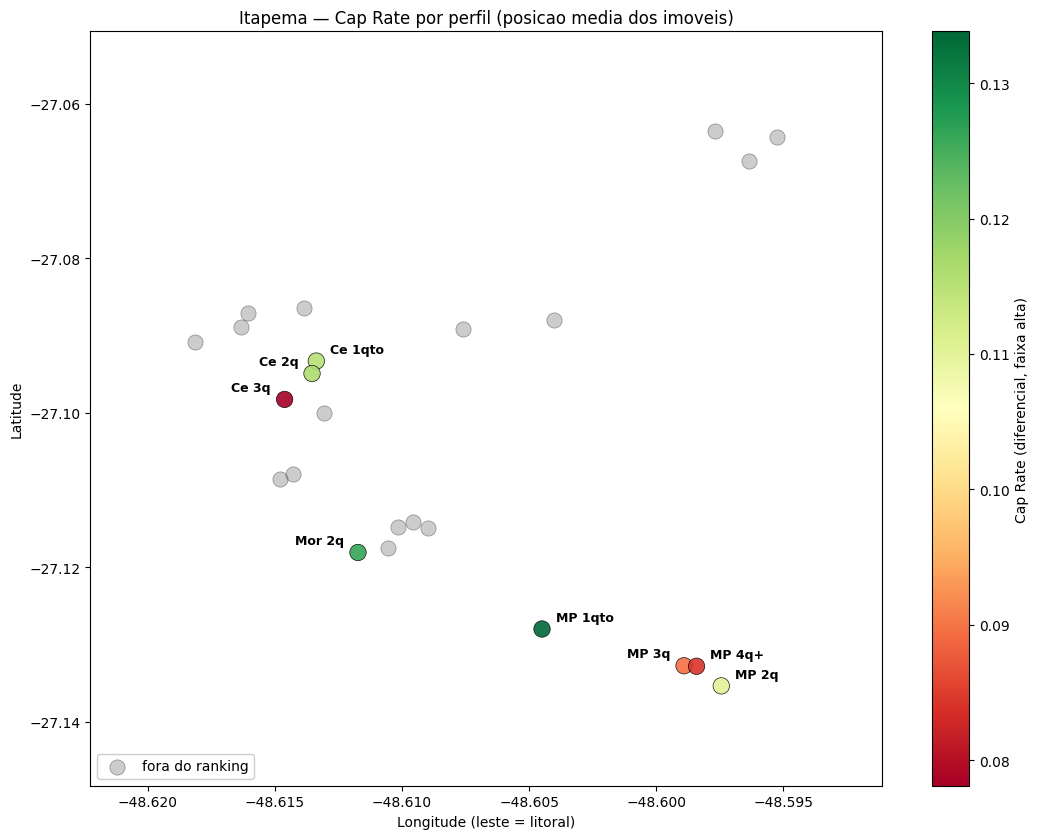

In [13]:
# Mapa estatico de Cap Rate (scatter otimizado: 1 ponto por celula)
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

a = _air_map[['latitude', 'longitude', 'bairro', 'tipo']].copy()
a = a.merge(_tab_map[['bairro', 'tipo', 'cap_cell']], on=['bairro', 'tipo'], how='left')
cel = a.groupby(['bairro', 'tipo'], as_index=False).agg(lat=('latitude', 'mean'), lon=('longitude', 'mean'))
cel = cel.merge(_tab_map[['bairro', 'tipo', 'cap_cell']], on=['bairro', 'tipo'], how='left')

fig, ax = plt.subplots(figsize=(11, 8.5))
cmap = plt.cm.RdYlGn
ok = cel.dropna(subset=['cap_cell']).copy()
norm = mcolors.Normalize(vmin=ok['cap_cell'].min(), vmax=ok['cap_cell'].max())
_abbr = {'meia praia': 'MP', 'centro': 'Ce', 'morretes': 'Mor', 'tabuleiro dos oliveiras': 'Tab',
         'casa branca': 'CB', 'alto sao bento': 'ASB', 'ilhota': 'Ilh', 'varzea': 'Var',
         'canto da praia': 'CP', 'sertao do trombudo': 'STT', 'sertaozinho': 'Sert'}

ax.scatter(ok['lon'], ok['lat'], c=[cmap(norm(v)) for v in ok['cap_cell']],
           s=140, alpha=0.9, edgecolors='k', linewidths=0.5, zorder=3)
fora = cel[cel['cap_cell'].isna()]
ax.scatter(fora['lon'], fora['lat'], c='gray', s=120, alpha=0.4,
           edgecolors='k', linewidths=0.5, zorder=2, label='fora do ranking')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cb = fig.colorbar(sm, ax=ax); cb.set_label('Cap Rate (diferencial, faixa alta)')
ax.set_title('Itapema \u2014 Cap Rate por perfil (posicao media dos imoveis)')
ax.set_xlabel('Longitude (leste = litoral)'); ax.set_ylabel('Latitude')
# folga nas bordas para os rotulos nao vazarem do eixo
ax.margins(0.18)
leg = ax.legend(loc='lower left', framealpha=0.95)

# --- declutter de rotulos ------------------------------------------------------
# Os pontos de bairro x tipo ficam quase sobrepostos (celulas do mesmo bairro
# compartilham o centroide). Em vez de um offset fixo, escolhemos para cada
# rotulo o primeiro offset candidato que nao colide com rotulos ja colocados,
# com os marcadores, nem com a legenda. Colisao medida em pixels (display coords).
fig.canvas.draw()
ocupados = []          # caixas (x0, y0, x1, y1) em pixels ja tomadas
PAD = 2.0

def _colide(box):
    x0, y0, x1, y1 = box
    for bx0, by0, bx1, by1 in ocupados:
        if x0 - PAD < bx1 and bx0 - PAD < x1 and y0 - PAD < by1 and by0 - PAD < y1:
            return True
    return False

# marcadores e legenda entram como regioes ocupadas desde o inicio
for _, r in cel.iterrows():
    px, py = ax.transData.transform((r['lon'], r['lat']))
    ocupados.append((px - 8, py - 8, px + 8, py + 8))
lb = leg.get_window_extent()
ocupados.append((lb.x0, lb.y0, lb.x1, lb.y1))

# candidatos: direita/esquerda/acima/abaixo, em dois raios
CAND = [(10, 6), (10, -12), (-10, 6), (-10, -12),
        (10, 20), (10, -26), (-10, 20), (-10, -26),
        (0, 26), (0, -32), (26, 0), (-26, 0)]

rot = ok[ok['bairro'].isin(_abbr)].sort_values('cap_cell', ascending=False)
for _, r in rot.iterrows():
    txt = '{} {}'.format(_abbr[r['bairro']], r['tipo'])
    px, py = ax.transData.transform((r['lon'], r['lat']))
    w, h = 6.4 * len(txt) + 4, 13.0           # estimativa da caixa de texto
    escolhido = None
    for dx, dy in CAND:
        x0 = px + dx if dx >= 0 else px + dx - w
        y0 = py + dy if dy >= 0 else py + dy
        box = (x0, y0, x0 + w, y0 + h)
        if not _colide(box):
            escolhido, caixa = (dx, dy), box
            break
    if escolhido is None:                      # sem vaga: usa o ultimo candidato
        escolhido, caixa = CAND[-1], (px, py, px + w, py + h)
    ocupados.append(caixa)
    dx, dy = escolhido
    ax.annotate(txt, (r['lon'], r['lat']), textcoords='offset points', xytext=(dx, dy),
                fontsize=9, fontweight='bold', zorder=5,
                ha='left' if dx >= 0 else 'right',
                bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='none', alpha=0.72),
                arrowprops=dict(arrowstyle='-', lw=0.6, color='0.35',
                                shrinkA=0, shrinkB=4) if abs(dx) + abs(dy) > 20 else None)

plt.tight_layout()
plt.show()


## 11. Considerações finais

### O que eu faria com mais uma semana

Os três pontos que **mudariam a resposta**, não apenas a precisão decimal.

**1. Sair da premissa de ocupação.** Todo Cap Rate aqui depende da faixa assumida de
45–70% — a maior incerteza do trabalho e a única capaz de inverter o ranking de novo.
Os dados dão uma pista: o `Price_AV` traz até 3 capturas por par *(imóvel, data de
estadia)*, e uma data que some entre capturas provavelmente foi reservada.

**2. Cap Rate líquido, não bruto.** Condomínio (preenchido em 70,1% dos anúncios) e IPTU
(67,4%) estão na base e foram tratados como campo indisponível. Com eles, o retorno sai
de bruto para líquido em dois terços da amostra — e o payback real cresce.

**3. Regressão para o sinal invertido.** Superhost, rating e nº de reviews aparecem com
efeito negativo na seção 8, o que tem mais cara de confundimento com gestão profissional
do que de descoberta. Uma regressão com controles diria qual dos dois é.

*Lista completa, com mais três itens de reforço de confiança, na seção 7 do relatório.*

### Uso da IA

Tratei a IA como parceira de raciocínio, não como executora: trabalhei pelo OpenCode com o
DeepSeek e usei o Claude Code numa segunda frente, de revisão e acabamento. O método foi
não aceitar a primeira resposta — foi assim que Morretes, descartado como "interior",
voltou ao ranking depois da checagem de longitude imóvel a imóvel, e que a reserva
instantânea caiu da recomendação ao se revelar proxy de gestão profissional. Onde o dado
ficou ambíguo, como no sinal invertido de superhost, registrei a dúvida em vez de inventar
explicação. O processo inteiro, iteração por iteração, está em `ai-log/`.
